Portrait plot

In [2]:
import numpy as np
import xarray as xr
import glob
import os

In [14]:
output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid_no = "144x72"
clim_period = "1981-2010"

var_name = "tas"
mdl_list = ['CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']

# Read observation climatology
obs_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.mon_clim{clim_period}.nc"    
ds = xr.open_dataset(obs_file)
obs_clim = ds.mean(dim="month")
ds.close()

no_models = len(mdl_list)
#no_leadtime = 5
#exp_out = "s1960-s2016"

no_leadtime = 1
exp_out = "historical"

#for j, lead in enumerate(range(1, no_leadtime + 1)):
for lead in range(1, no_leadtime + 1):

    all_mdl_ds = []
    ensemble_start = 1 
    
    for idx, model in enumerate(mdl_list):

        # Read model climatology and define bias
        mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.YR{lead}.mon_clim{clim_period}.em.nc"    
        ds = xr.open_dataset(mdl_file)
        mdl_clim = ds.mean(dim="month")
        ds.close()
    
        bias = mdl_clim[f"{var_name}"] - obs_clim[f"{var_name}"]
        
        ensemble_no = 10
        if exp_out != "historical" and model == "FGOALS-f3-L":
            ensemble_no = 9
        if exp_out == "historical" and model == "FGOALS-f3-L":
            ensemble_no = 3
        if exp_out == "historical" and model == "HadGEM3-GC31-MM":
            ensemble_no = 4

        if exp_out == "historical":
            file = os.path.join(output_dir, f"{model}", f"{var_name}.144x72.{exp_out}.1961-2014.r1-{ensemble_no}.nc")  
            ds = xr.open_dataset(file)
            ei_ds = ds
        else:
            file = os.path.join(output_dir, f"{model}", f"{var_name}.144x72.{exp_out}.YR{lead}.r1-{ensemble_no}.nc")  
            ds = xr.open_dataset(file)
            ei_ds = ds[f"{var_name}"] - bias
            
        ds.close()
        n_ens = ei_ds.sizes['ensemble']
        print(model, n_ens, file)
        new_ens_range = range(ensemble_start, ensemble_start + n_ens)

        ei_ds = ei_ds.assign_coords(ensemble=new_ens_range)   
        all_mdl_ds.append(ei_ds)
        ensemble_start += n_ens

    #print(all_mdl_ds)
    mme_ds = xr.concat(all_mdl_ds, dim="ensemble", coords='minimal')
    print(mme_ds)
    n_tot = mme_ds.sizes['ensemble']

    if (exp_out == "historical"):
        output_filename = f"{output_dir}/MME/{var_name}_bc.144x72.{exp_out}.1961-2014.r1-{n_tot}.nc"
    else:
        output_filename = f"{output_dir}/MME/{var_name}_bc.144x72.{exp_out}.YR{lead}.r1-{n_tot}.nc"
        
    if os.path.exists(output_filename):
        os.remove(output_filename)
    mme_ds.to_netcdf(output_filename)
    print(f"%% MME Regrid time-averaged dataset saved: {output_filename}")        

CanESM5 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/CanESM5/tas.144x72.historical.1961-2014.r1-10.nc
CMCC-CM2-SR5 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/CMCC-CM2-SR5/tas.144x72.historical.1961-2014.r1-10.nc
CNRM-ESM2-1 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/CNRM-ESM2-1/tas.144x72.historical.1961-2014.r1-10.nc
EC-Earth3 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/EC-Earth3/tas.144x72.historical.1961-2014.r1-10.nc
FGOALS-f3-L 3 /pscratch/sd/j/jungchoi/DCPP/_metrics/FGOALS-f3-L/tas.144x72.historical.1961-2014.r1-3.nc
HadGEM3-GC31-MM 4 /pscratch/sd/j/jungchoi/DCPP/_metrics/HadGEM3-GC31-MM/tas.144x72.historical.1961-2014.r1-4.nc
IPSL-CM6A-LR 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/IPSL-CM6A-LR/tas.144x72.historical.1961-2014.r1-10.nc
MIROC6 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/MIROC6/tas.144x72.historical.1961-2014.r1-10.nc
MPI-ESM1-2-HR 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/MPI-ESM1-2-HR/tas.144x72.historical.1961-2014.r1-10.nc
MRI-ESM2-0 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/MRI-

Text(0.5, 1.0, 'TAS Mean Bias (ref: ERA5 1981-2010)')

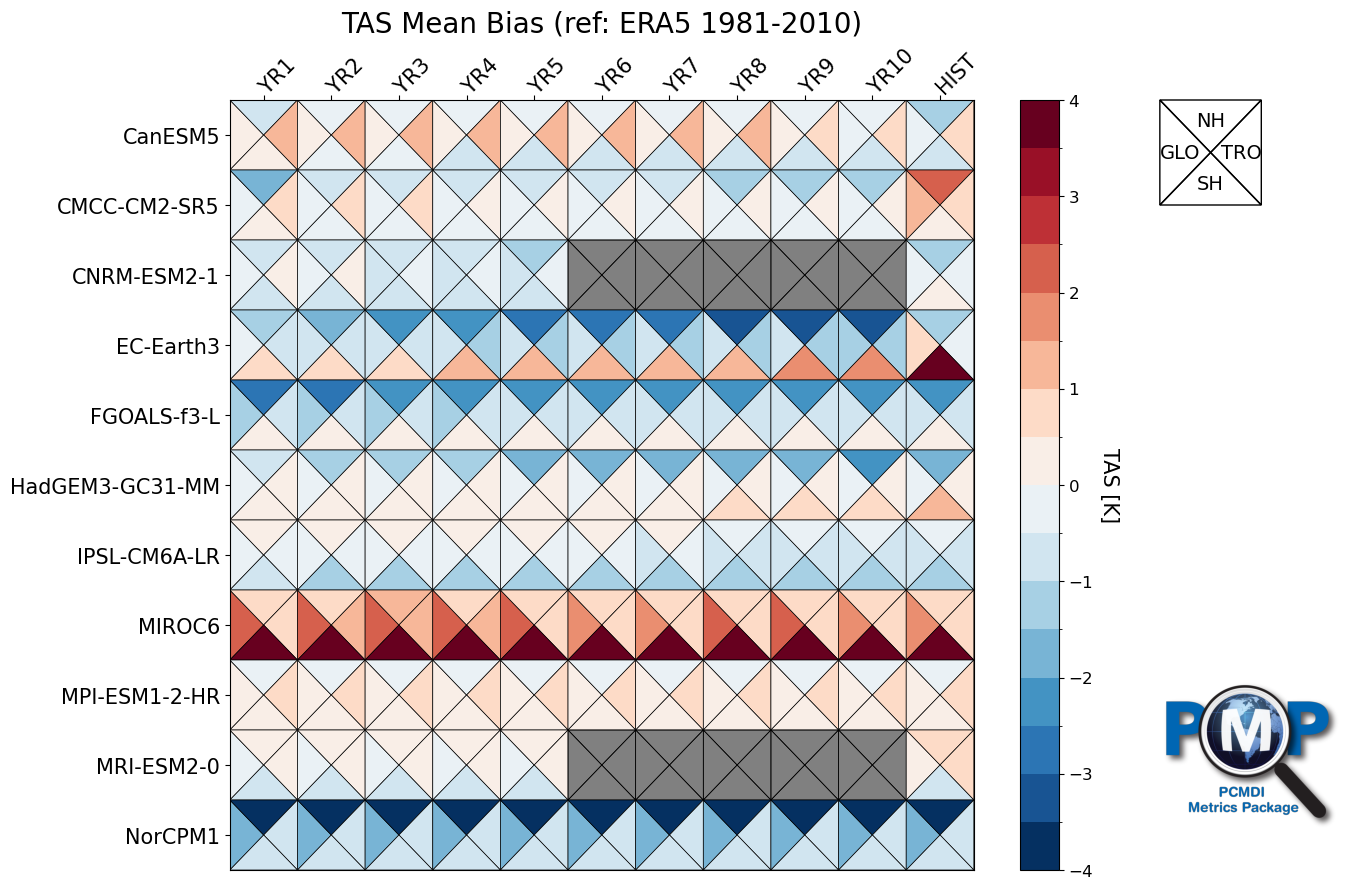

In [47]:
#xaxis_labels = ['Lead YR1', 'Lead YR2', 'Lead YR3', 'Lead YR4', 'Lead YR5', 'historical']
#yaxis_labels = ['BCC-CSM2-MR', 'CanESM5', 'CMCC-CM2-SR5', 'EC-Earth3', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']

#xaxis_labels = ['Lead YR1', 'Lead YR2', 'Lead YR3', 'Lead YR4', 'Lead YR5', 'Lead YR6', 'Lead YR7', 'Lead YR8', 'Lead YR9', 'Lead YR10']
xaxis_labels = ['YR1', 'YR2', 'YR3', 'YR4', 'YR5', 'YR6', 'YR7', 'YR8', 'YR9', 'YR10', 'HIST']
yaxis_labels = mdl_list

xaxis_labels = [''+x for x in xaxis_labels]
yaxis_labels = [''+y for y in yaxis_labels]

fig, ax, cbar = portrait_plot([data1, data2, data3, data4],  # or np.stack([data1, data2]) for (upper, lower)
                              xaxis_labels=xaxis_labels,
                              yaxis_labels=yaxis_labels,
                              cbar_label='TAS [K]',
                              #cbar_label='PR [mm/d]',
                              legend_on=True,
                              cmap_bounds=[-4, -3.5, -3, -2.5, -2, -1.5, -1, -.5, 0, .5, 1, 1.5, 2, 2.5, 3, 3.5, 4],
                              #cmap="BrBG",
                              #cmap_bounds=[-.8, -.7, -.6, -.5, -.4, -.3, -.2, -.1, 0, .1, .2, .3, .4, .5, .6, .7, .8],
                              missing_color='grey',
                              legend_labels=['NH', 'TRO', 'SH', 'GLO'])

ax.set_title("TAS Mean Bias (ref: ERA5 1981-2010)", fontsize=20, pad=10)
#ax.set_title("PR Mean Bias (ref: GPCP 1981-2010)", fontsize=20, pad=10)